# 0. Import library and load data

In [1]:
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt
import seaborn as sns
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
sns.set(style="whitegrid")
import re

In [2]:
df = pd.read_json("../../Data/Shopee/cleaned_shopee_data.json")

# 1. Overview

Currently, our data has 44937 rows of productions and 19 columns of attributes. To be specific, this includes:

In [3]:
print(df.shape)              

(44937, 19)


In [4]:
df.describe()

,Ma_san_pham,Ma_cua_hang,Gia,Gia_goc,Phan_tram_giam_gia,Diem_hai_long,So_danh_gia,Doanh_so_thang,Doanh_so_tong,Luot_thich,So_ngay_da_ban
count,4.493700e+04,4.493700e+04,4.493700e+04,4.493700e+04,44937.000000,44937.000000,44937.000000,4.493700e+04,4.493700e+04,44937.000000,44937.000000
mean,3.216423e+10,7.713369e+08,3.396523e+05,4.194233e+05,19.482662,3.978444,963.926608,6.250757e+03,1.112777e+04,775.844627,653.114316
std,1.517350e+10,5.931190e+08,2.883059e+06,3.230501e+06,19.009871,1.901151,6509.959042,9.209599e+04,1.044676e+05,4158.721867,661.908743
min,8.300150e+05,1.364400e+04,1.000000e+03,1.000000e+03,0.000000,0.000000,0.000000,0.000000e+00,0.000000e+00,0.000000,0.000000
25%,2.276688e+10,1.815853e+08,5.704000e+04,7.000000e+04,0.000000,4.710000,2.000000,2.000000e+00,1.900000e+01,1.000000,130.000000
50%,2.820720e+10,7.343347e+08,1.130690e+05,1.500000e+05,16.700000,4.910000,63.000000,4.700000e+01,4.890000e+02,16.000000,439.000000
75%,4.485769e+10,1.329548e+09,2.100000e+05,2.889000e+05,34.700000,4.960000,430.000000,7.890000e+02,3.000000e+03,152.000000,965.000000
max,5.815827e+10,1.793961e+09,1.200000e+08,1.200000e+08,99.100000,5.000000,804240.000000,1.000000e+07,1.000000e+07,188903.000000,3882.000000


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 44937 entries, 0 to 44936
Data columns (total 19 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Danh_muc_chinh       44937 non-null  object 
 1   Danh_muc_phu         44937 non-null  object 
 2   Ma_san_pham          44937 non-null  int64  
 3   Ma_cua_hang          44937 non-null  int64  
 4   Ten_san_pham         44937 non-null  object 
 5   Gia                  44937 non-null  int64  
 6   Gia_goc              44937 non-null  int64  
 7   Phan_tram_giam_gia   44937 non-null  float64
 8   Diem_hai_long        44937 non-null  float64
 9   So_danh_gia          44937 non-null  int64  
 10  Doanh_so_thang       44937 non-null  int64  
 11  Doanh_so_tong        44937 non-null  int64  
 12  Luot_thich           44937 non-null  int64  
 13  Dia_diem_cua_hang    44937 non-null  object 
 14  La_mall              44937 non-null  bool   
 15  Da_xac_thuc          44937 non-null 

# 2. Univariate Analysis

## 2.1 ``Danh_muc_chinh`` & ``Danh_muc_phu``

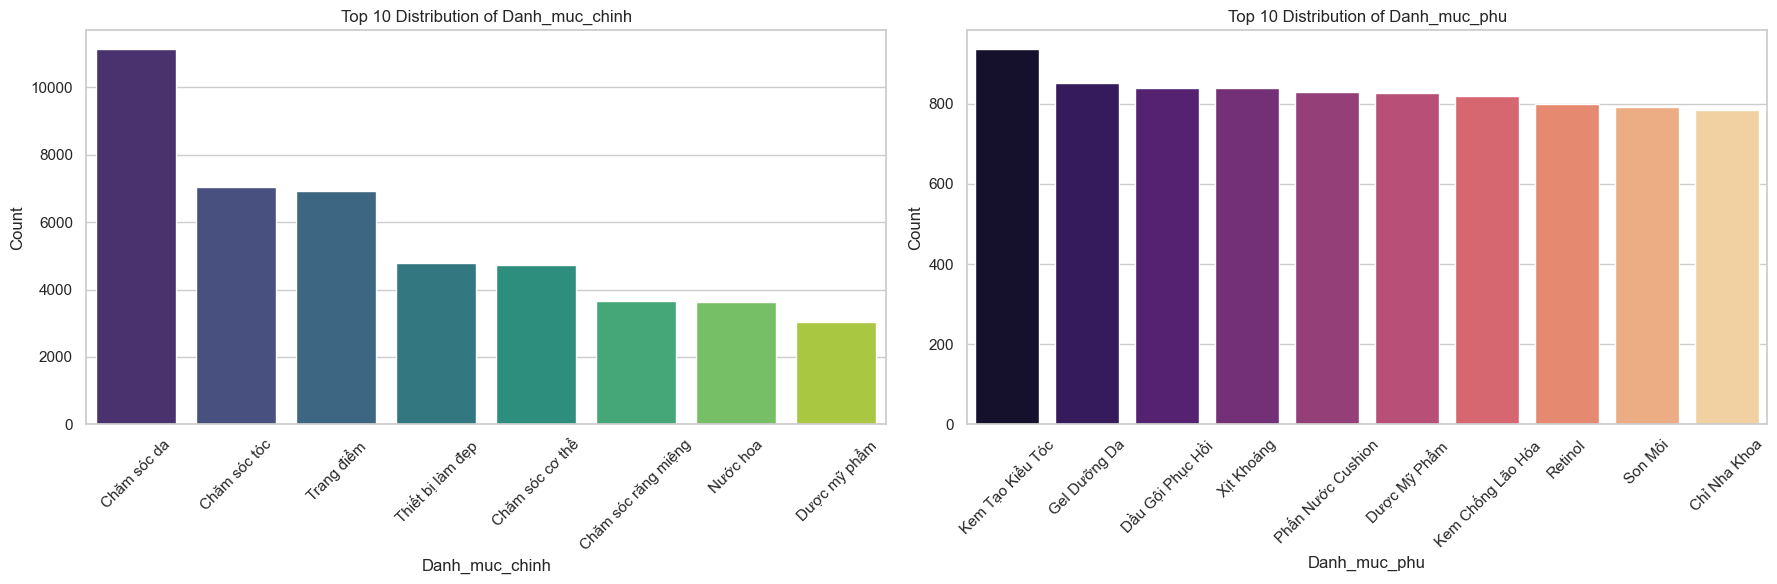

In [6]:
import warnings
warnings.filterwarnings("ignore")

# Top 10 category
category_main_counts = df['Danh_muc_chinh'].value_counts()
category_sub_counts = df['Danh_muc_phu'].value_counts()

top10_main = category_main_counts.head(10)
top10_sub = category_sub_counts.head(10)

fig, axes = plt.subplots(1, 2, figsize=(18,6))

# Plot Danh_muc_chinh top 10
sns.barplot(x=top10_main.index, y=top10_main.values, palette='viridis', ax=axes[0])
axes[0].set_title("Top 10 Distribution of Danh_muc_chinh")
axes[0].set_xlabel("Danh_muc_chinh")
axes[0].set_ylabel("Count")
axes[0].tick_params(axis='x', rotation=45)

# Plot Danh_muc_phu top 10
sns.barplot(x=top10_sub.index, y=top10_sub.values, palette='magma', ax=axes[1])
axes[1].set_title("Top 10 Distribution of Danh_muc_phu")
axes[1].set_xlabel("Danh_muc_phu")
axes[1].set_ylabel("Count")
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

## 2.2 ``Gia``

We will check the proportion of outliers in ``Gia`` attribute as well as plotting its distribution.

In [ ]:
def detect_outliers(df, col):
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    in_range = df[(df[col] >= lower_bound) & (df[col] <= upper_bound)][col]
    out_range = df[(df[col] < lower_bound) | (df[col] > upper_bound)][col]
    
    outlier_ratio = len(out_range) / len(df) * 100
    print(f"Outliers in {col}: {len(out_range)} entries ({outlier_ratio:.2f}%)")
    
    return in_range, out_range, outlier_ratio

def plot_outliers_distribution(in_range, bins, col):
    fig, ax = plt.subplots(1, 1, figsize=(16,5))  
    
    # Plot in-range
    sns.histplot(in_range, bins=bins, kde=True, ax=ax, color='green')
    ax.set_title(f'{col} Distribution (Within Range)')
    ax.set_xlabel(col)
    ax.set_ylabel('Count')
    
    plt.tight_layout()
    plt.show()

In [8]:
in_range, out_range, outlier_ratio = detect_outliers(df, 'Gia')

Outliers in Gia: 3755 entries (8.36%)


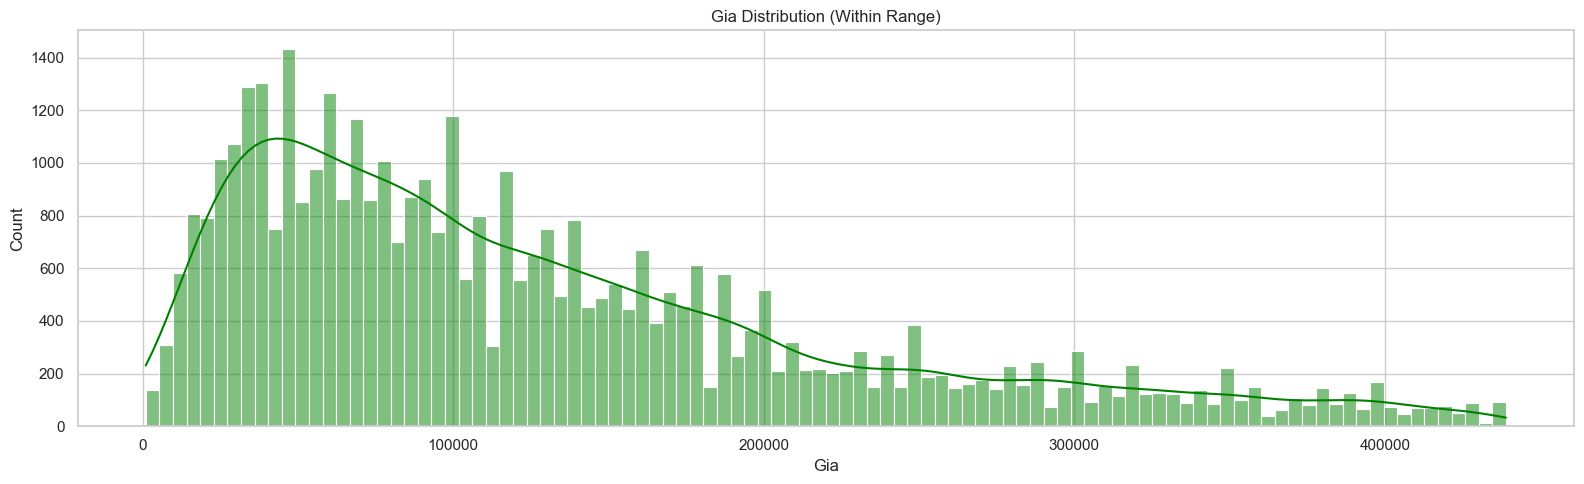

In [9]:
plot_outliers_distribution(in_range, 100, 'Gia')

## 2.3 ``Danh_gia`` & ``So_danh_gia``

In [11]:
in_range, out_range, outlier_ratio = detect_outliers(df, 'Diem_hai_long')

Outliers in Diem_hai_long: 9134 entries (20.33%)


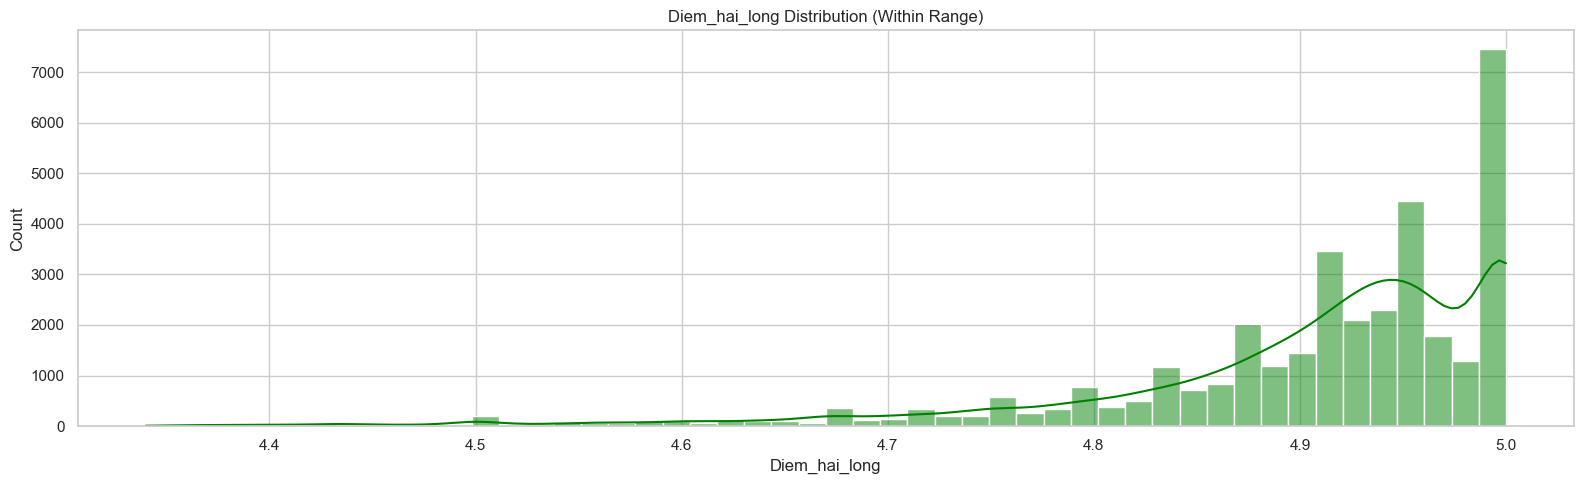

In [12]:
plot_outliers_distribution(in_range, 50, 'Diem_hai_long')

In [13]:
in_range, out_range, outlier_ratio = detect_outliers(df, 'So_danh_gia')

Outliers in So_danh_gia: 5938 entries (13.21%)


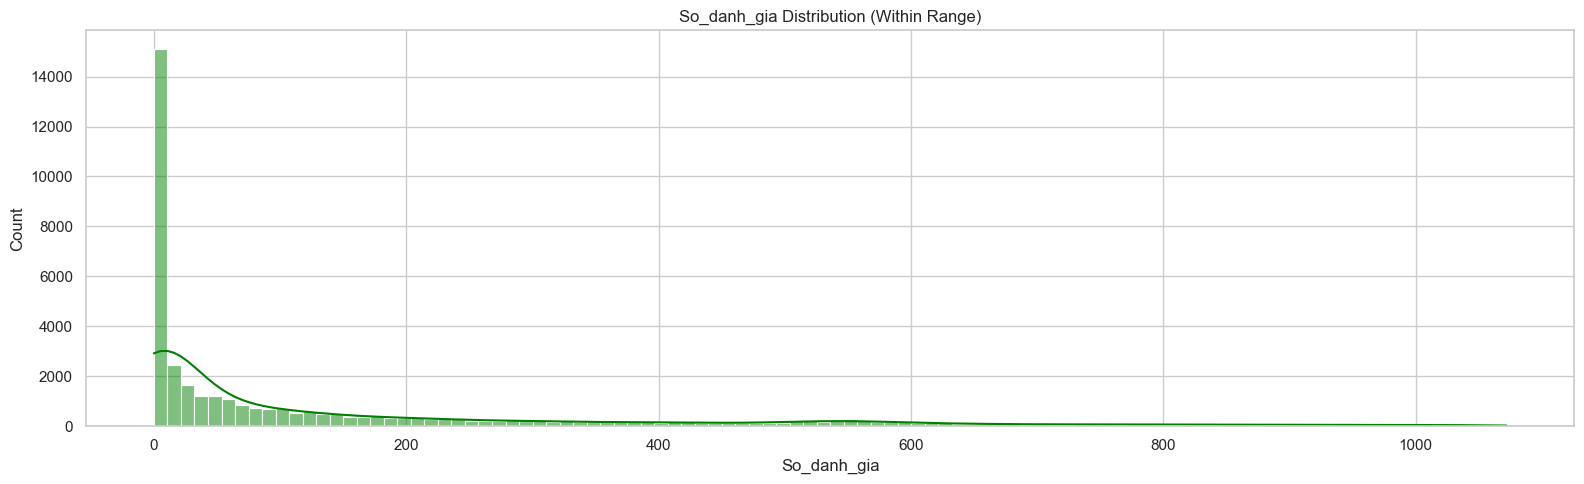

In [14]:
plot_outliers_distribution(in_range, 100, 'So_danh_gia')

## 2.4 ``Doanh_so_thang`` & ``Doanh_so_tong``

In [15]:
in_range, out_range, outlier_ratio = detect_outliers(df, 'Doanh_so_thang')

Outliers in Doanh_so_thang: 7714 entries (17.17%)


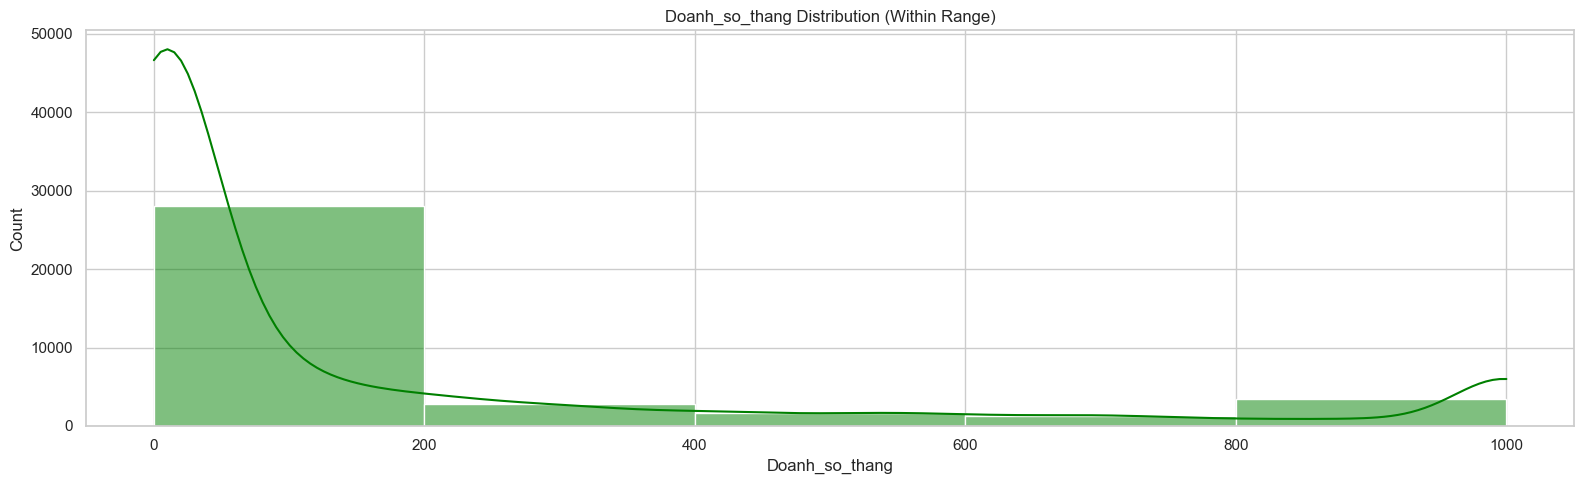

In [21]:
plot_outliers_distribution(in_range, 5, 'Doanh_so_thang')

In [22]:
in_range, out_range, outlier_ratio = detect_outliers(df, 'Doanh_so_tong')

Outliers in Doanh_so_tong: 6860 entries (15.27%)


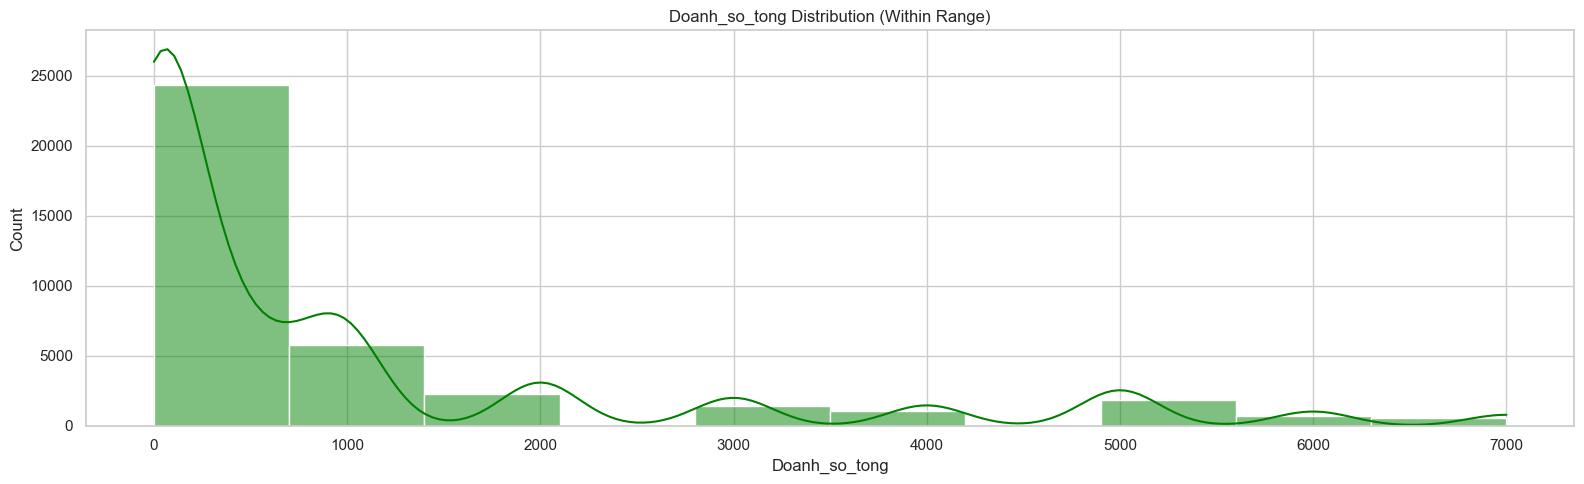

In [28]:
plot_outliers_distribution(in_range, 10, 'Doanh_so_tong')

# 3. Bivariate Analysis

Besides the attributes which have already had linear relationship with others, we can see the strong correlation between:
 ``Doanh_so_thang``, ``Doanh_so_tong``, ``Luot_thich`` and ``So_danh_gia``, respectively. This means the more products you sell, the more reviews you get which also means your reputation is growing along with your number of sold products

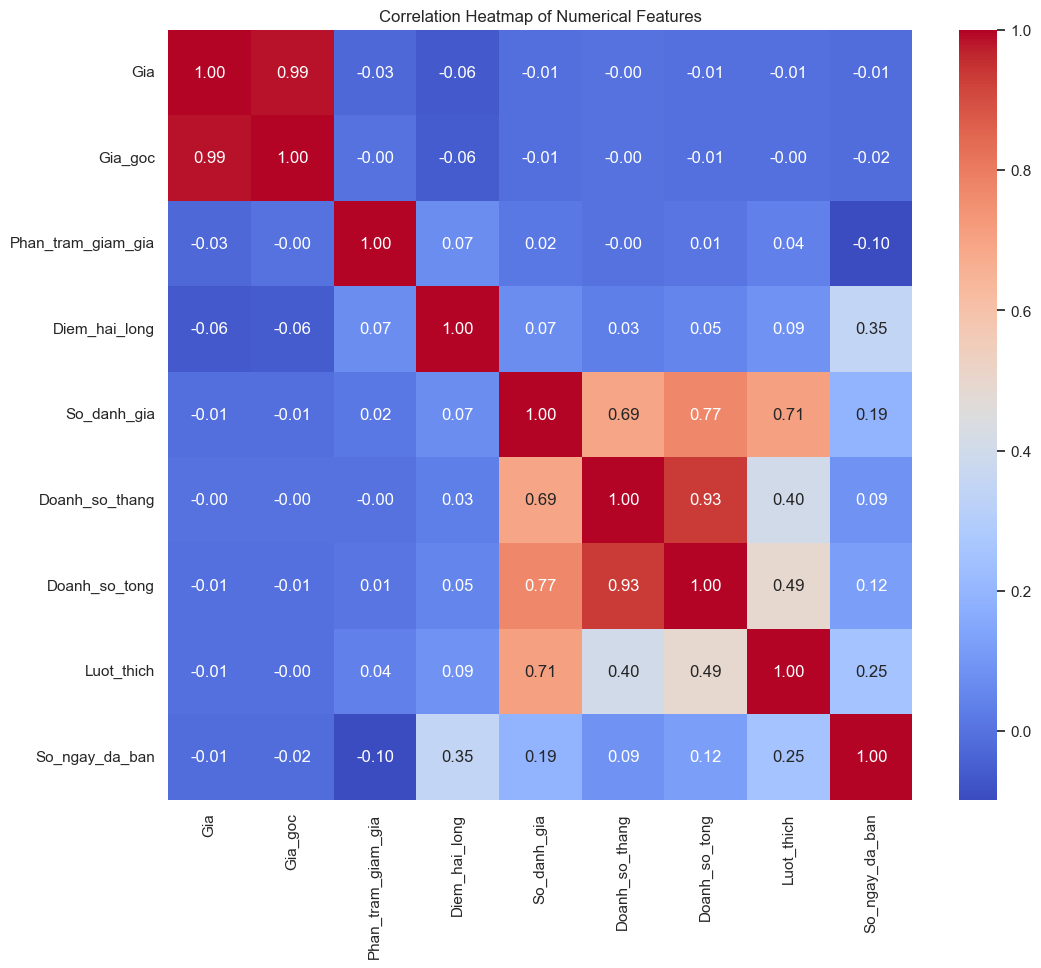

In [29]:
import seaborn as sns
import matplotlib.pyplot as plt

numerical_cols = ['Gia', 'Gia_goc', 'Phan_tram_giam_gia', 'Diem_hai_long', 
                  'So_danh_gia', 'Doanh_so_thang', 'Doanh_so_tong', 'Luot_thich', 'So_ngay_da_ban']

plt.figure(figsize=(12,10))
sns.heatmap(df[numerical_cols].corr(), annot=True, fmt=".2f", cmap='coolwarm')
plt.title("Correlation Heatmap of Numerical Features")
plt.show()

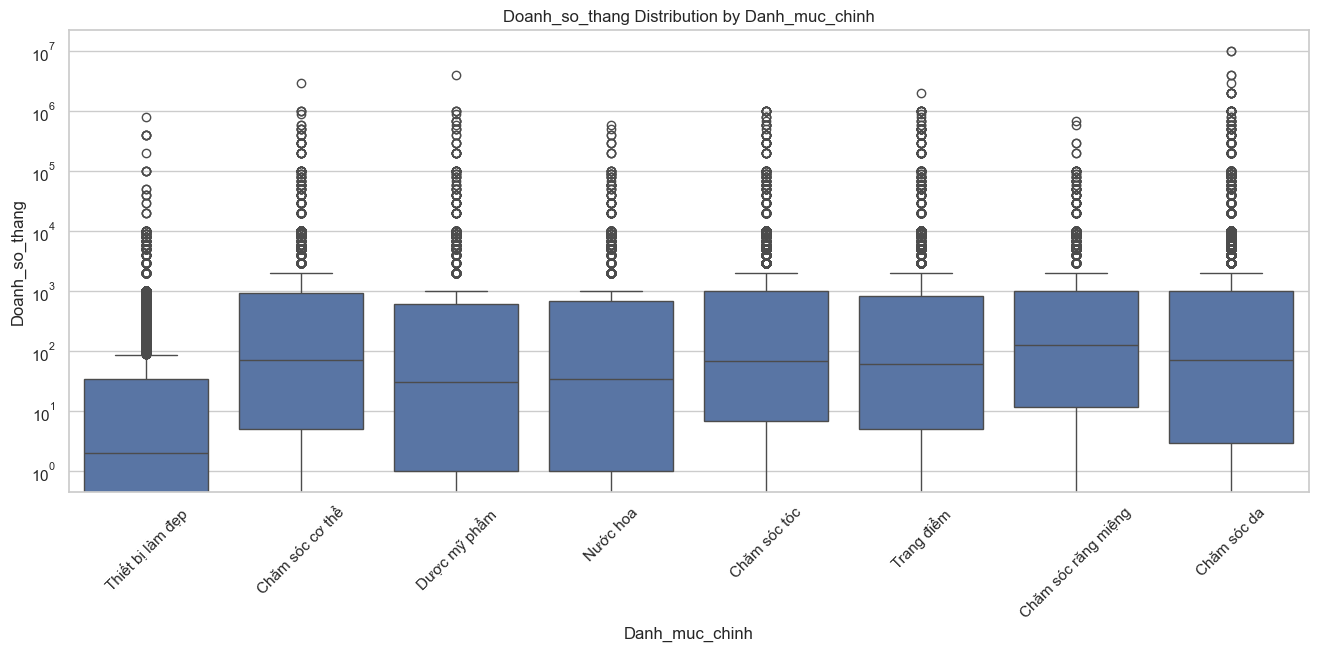

In [33]:
plt.figure(figsize=(16,6))
sns.boxplot(x='Danh_muc_chinh', y='Doanh_so_thang', data=df)
plt.yscale('log')
plt.xticks(rotation=45)
plt.title("Doanh_so_thang Distribution by Danh_muc_chinh")
plt.show()

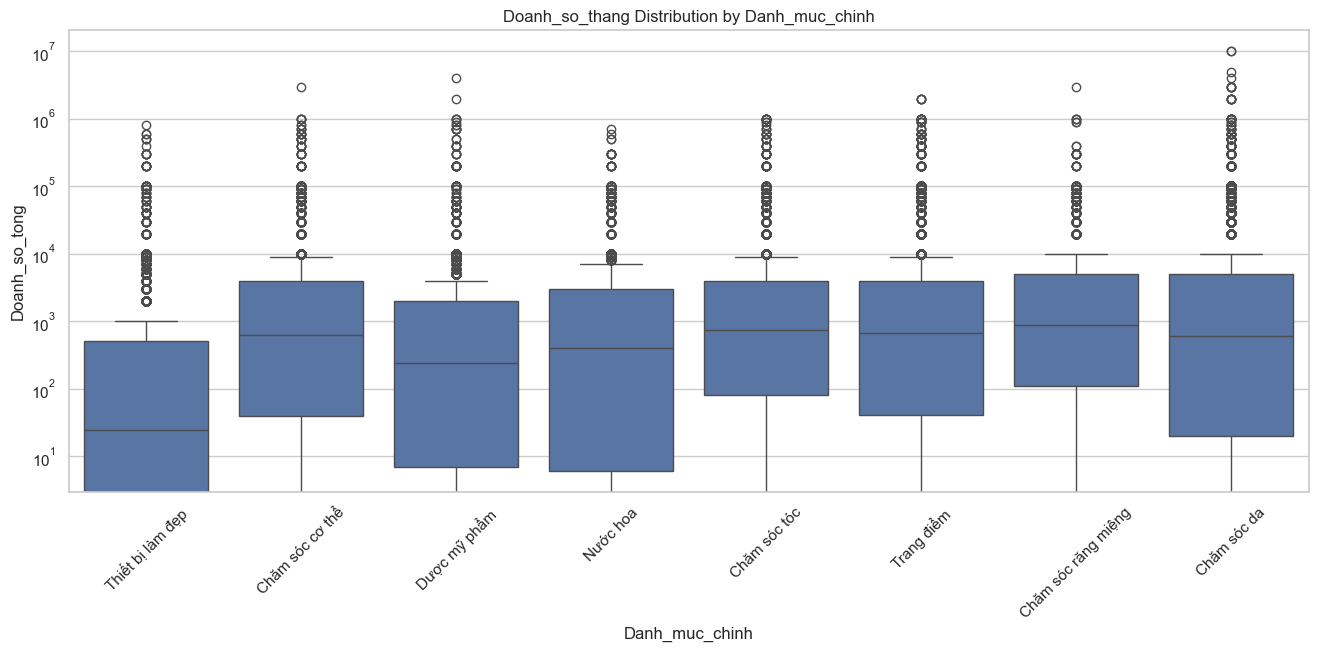

In [34]:
plt.figure(figsize=(16,6))
sns.boxplot(x='Danh_muc_chinh', y='Doanh_so_tong', data=df)
plt.yscale('log')
plt.xticks(rotation=45)
plt.title("Doanh_so_thang Distribution by Danh_muc_chinh")
plt.show()

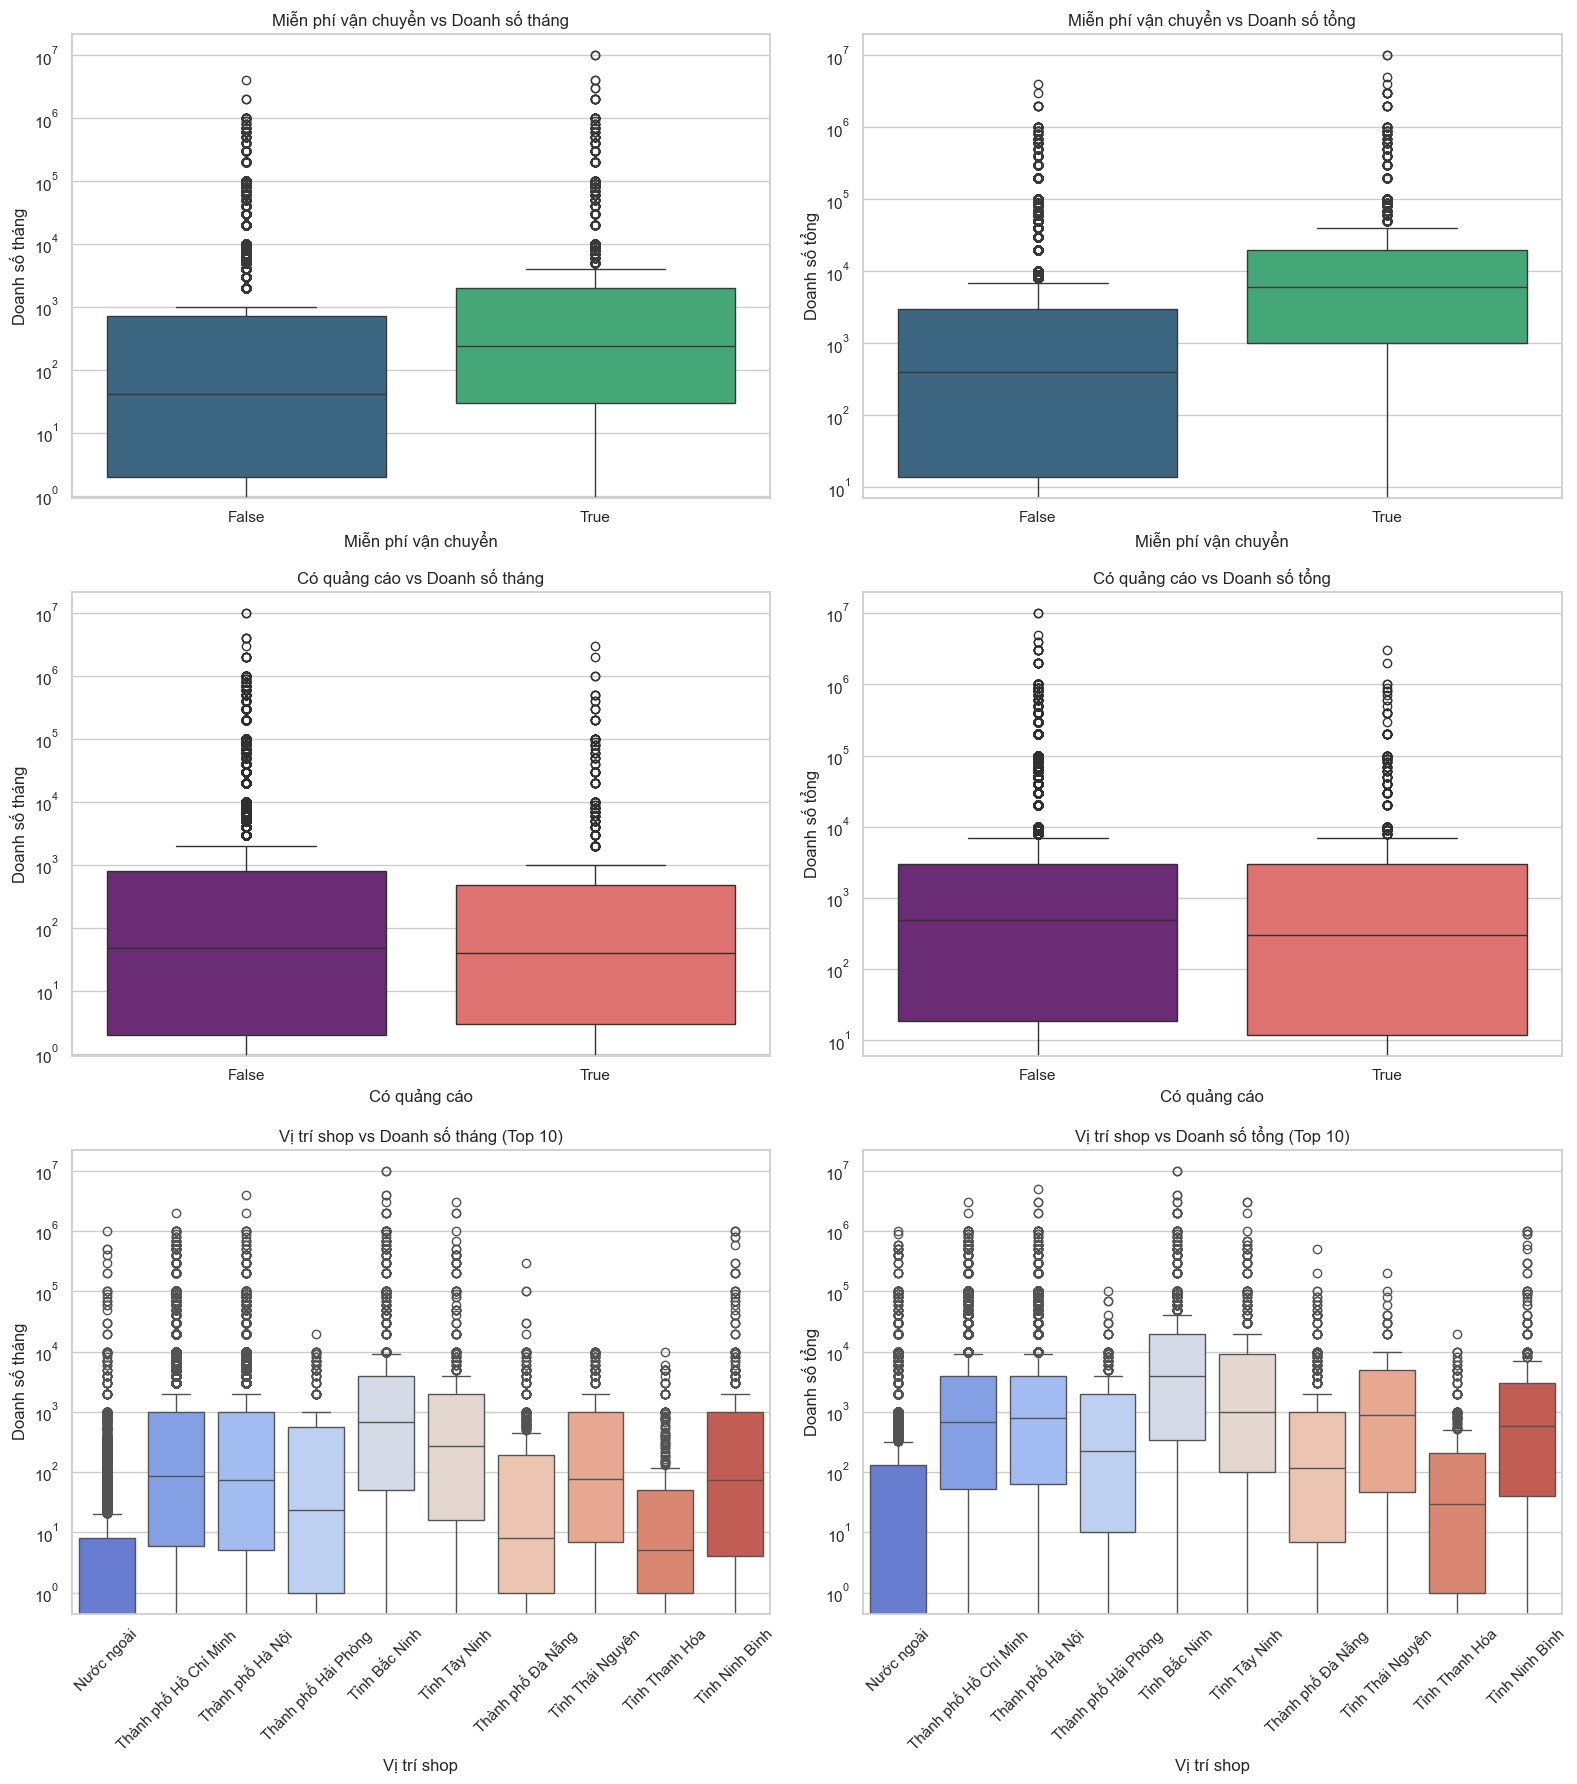

In [36]:
top_shop_locations = df['Dia_diem_cua_hang'].value_counts().index[:10]

fig, axes = plt.subplots(3, 2, figsize=(16,18))

# -------------------------------
# 1. Mien_phi_van_chuyen
# -------------------------------
sns.boxplot(x='Mien_phi_van_chuyen', y='Doanh_so_thang', data=df, palette='viridis', ax=axes[0,0])
axes[0,0].set_title('Miễn phí vận chuyển vs Doanh số tháng')
axes[0,0].set_xlabel('Miễn phí vận chuyển')
axes[0,0].set_ylabel('Doanh số tháng')
axes[0,0].set_yscale('log')  # log scale

sns.boxplot(x='Mien_phi_van_chuyen', y='Doanh_so_tong', data=df, palette='viridis', ax=axes[0,1])
axes[0,1].set_title('Miễn phí vận chuyển vs Doanh số tổng')
axes[0,1].set_xlabel('Miễn phí vận chuyển')
axes[0,1].set_ylabel('Doanh số tổng')
axes[0,1].set_yscale('log')  # log scale

# -------------------------------
# 2. Quang cao
# -------------------------------
sns.boxplot(x='Co_quang_cao', y='Doanh_so_thang', data=df, palette='magma', ax=axes[1,0])
axes[1,0].set_title('Có quảng cáo vs Doanh số tháng')
axes[1,0].set_xlabel('Có quảng cáo')
axes[1,0].set_ylabel('Doanh số tháng')
axes[1,0].set_yscale('log')  # log scale

sns.boxplot(x='Co_quang_cao', y='Doanh_so_tong', data=df, palette='magma', ax=axes[1,1])
axes[1,1].set_title('Có quảng cáo vs Doanh số tổng')
axes[1,1].set_xlabel('Có quảng cáo')
axes[1,1].set_ylabel('Doanh số tổng')
axes[1,1].set_yscale('log')  # log scale

# -------------------------------
# 3. Vi tri shop
# -------------------------------
df_location = df[df['Dia_diem_cua_hang'].isin(top_shop_locations)]

sns.boxplot(x='Dia_diem_cua_hang', y='Doanh_so_thang', data=df_location, palette='coolwarm', ax=axes[2,0])
axes[2,0].set_title('Vị trí shop vs Doanh số tháng (Top 10)')
axes[2,0].set_xlabel('Vị trí shop')
axes[2,0].set_ylabel('Doanh số tháng')
axes[2,0].tick_params(axis='x', rotation=45)
axes[2,0].set_yscale('log')  # log scale

sns.boxplot(x='Dia_diem_cua_hang', y='Doanh_so_tong', data=df_location, palette='coolwarm', ax=axes[2,1])
axes[2,1].set_title('Vị trí shop vs Doanh số tổng (Top 10)')
axes[2,1].set_xlabel('Vị trí shop')
axes[2,1].set_ylabel('Doanh số tổng')
axes[2,1].tick_params(axis='x', rotation=45)
axes[2,1].set_yscale('log')  # log scale

plt.tight_layout()
plt.show()